# Objetivo do trabalho
Uso da ResNet50 para detecção de cancer de intestino

### Download do LC25000 através do kaggle

In [ ]:
from google.colab import files
!pip install -q kaggle

In [ ]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip

def unzip_support_functions_in_colab():
    !kaggle datasets download -d gabrielcruzvazsantos/colon-detection-support-functions
    !unzip -q colon-detection-support-functions.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()
    unzip_support_functions_in_colab()

In [ ]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.75G/1.76G [00:21<00:00, 234MB/s]
100% 1.76G/1.76G [00:21<00:00, 89.4MB/s]
Dataset URL: https://www.kaggle.com/datasets/gabrielcruzvazsantos/colon-detection-support-functions
License(s): unknown
  0% 0.00/3.86k [00:00<?, ?B/s]
100% 3.86k/3.86k [00:00<00:00, 18.0MB/s]


## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

In [ ]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders
from train_and_test_model import train_model, test_model


In [ ]:
import torch
import torchvision
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns


### Datasets e dataLoader

In [ ]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 25849.67it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [ ]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, 64)

### Modelo e treinamento
- ResNet50
- Canais de entrada - imagem RGB: 3
- Saída - Problema de classificação binária: 2
- Taxa de aprendizado: 0.002
- Otimizador: Adamax
- β1 = 0.9, β2 = 0.999
- Weight Decay: 1e-4
- Batch size = 64

In [ ]:
in_channels = 3
output_features = 2
learning_rate = 1e-2
weight_decay = 1e-4

In [ ]:
model = torchvision.models.resnet50(num_classes=output_features)
model = model.to("cuda")

In [ ]:
optimizer = torch.optim.Adamax(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08, weight_decay=weight_decay)

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer)

Epoch 1/10 | Train Loss: 0.3856 | Val Loss: 0.1487 | Sem melhora: 0/5
Epoch 2/10 | Train Loss: 0.0657 | Val Loss: 0.0394 | Sem melhora: 0/5
Epoch 3/10 | Train Loss: 0.0597 | Val Loss: 0.6691 | Sem melhora: 1/5
Epoch 4/10 | Train Loss: 0.0378 | Val Loss: 0.0160 | Sem melhora: 0/5
Epoch 5/10 | Train Loss: 0.0286 | Val Loss: 0.1212 | Sem melhora: 1/5
Epoch 6/10 | Train Loss: 0.0419 | Val Loss: 0.0652 | Sem melhora: 2/5
Epoch 7/10 | Train Loss: 0.0159 | Val Loss: 0.3898 | Sem melhora: 3/5
Epoch 8/10 | Train Loss: 0.0163 | Val Loss: 0.0625 | Sem melhora: 4/5
Epoch 9/10 | Train Loss: 0.0329 | Val Loss: 0.0668 | Sem melhora: 5/5

Early stopping ativado! Melhor Val Loss: 0.0160


#### imprimindo resultados do treinamento e validação

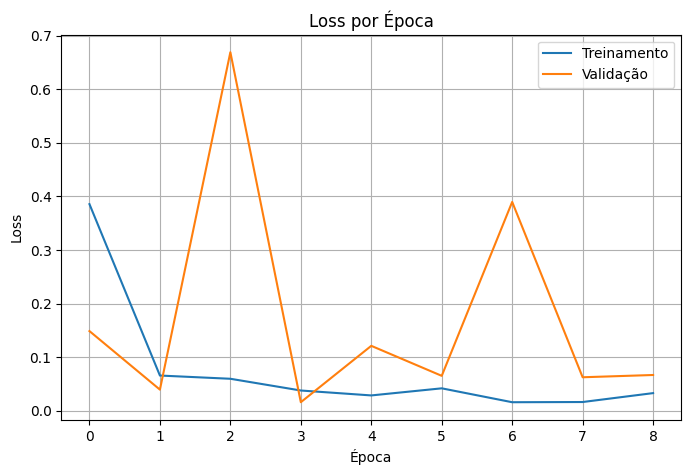

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Testando modelo

In [ ]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 0.9925
Precisão (weighted): 0.9925
Recall (weighted): 0.9925
F1-score (weighted): 0.9925
Matriz de Confusão:
[[989  11]
 [  4 996]]


In [ ]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.9925 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9925 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.9925 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9925 │
╘═════════════════════╧═════════╛


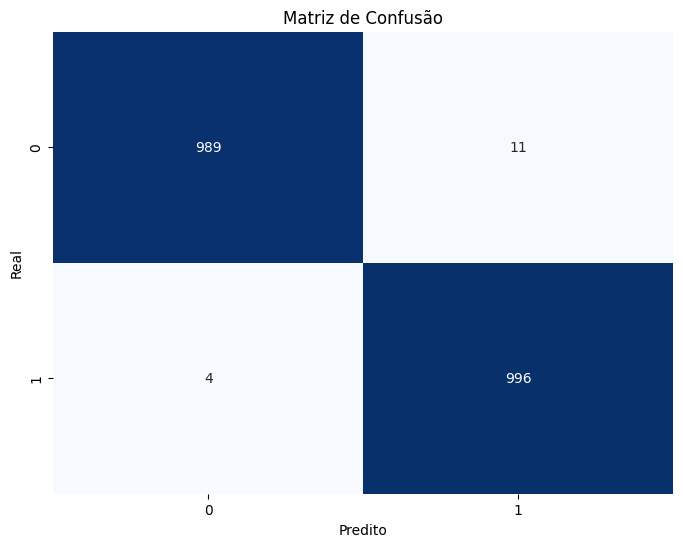

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Próxima etapa: aumentar o número de épocas: 50

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 50)

Epoch 1/50 | Train Loss: 0.5118 | Val Loss: 0.1319 | Sem melhora: 0/50
Epoch 2/50 | Train Loss: 0.0943 | Val Loss: 0.0841 | Sem melhora: 0/50
Epoch 3/50 | Train Loss: 0.0710 | Val Loss: 0.0364 | Sem melhora: 0/50
Epoch 4/50 | Train Loss: 0.0497 | Val Loss: 0.1778 | Sem melhora: 1/50
Epoch 5/50 | Train Loss: 0.0330 | Val Loss: 0.1232 | Sem melhora: 2/50
Epoch 6/50 | Train Loss: 0.0377 | Val Loss: 0.6664 | Sem melhora: 3/50
Epoch 7/50 | Train Loss: 0.0247 | Val Loss: 0.0086 | Sem melhora: 0/50
Epoch 8/50 | Train Loss: 0.0234 | Val Loss: 2.5312 | Sem melhora: 1/50
Epoch 9/50 | Train Loss: 0.0343 | Val Loss: 0.3211 | Sem melhora: 2/50
Epoch 10/50 | Train Loss: 0.0275 | Val Loss: 0.0262 | Sem melhora: 3/50
Epoch 11/50 | Train Loss: 0.0158 | Val Loss: 0.0346 | Sem melhora: 4/50
Epoch 12/50 | Train Loss: 0.0109 | Val Loss: 0.2778 | Sem melhora: 5/50
Epoch 13/50 | Train Loss: 0.0125 | Val Loss: 1.2047 | Sem melhora: 6/50
Epoch 14/50 | Train Loss: 0.0293 | Val Loss: 0.0216 | Sem melhora: 7/50
E

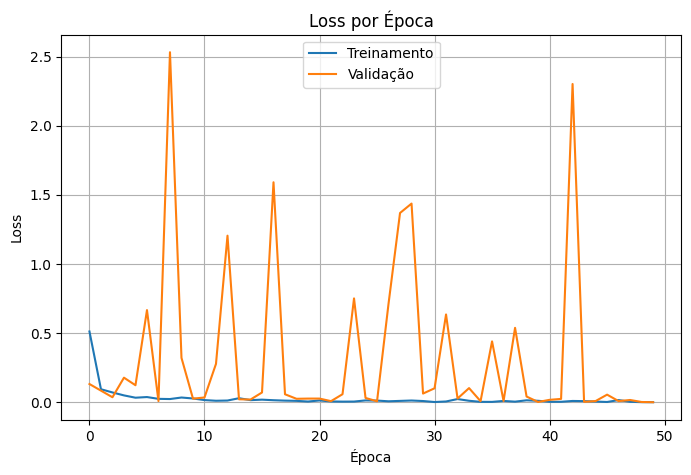

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 1.0000
Precisão (weighted): 1.0000
Recall (weighted): 1.0000
F1-score (weighted): 1.0000
Matriz de Confusão:
[[1000    0]
 [   0 1000]]


In [ ]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │       1 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │       1 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │       1 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │       1 │
╘═════════════════════╧═════════╛


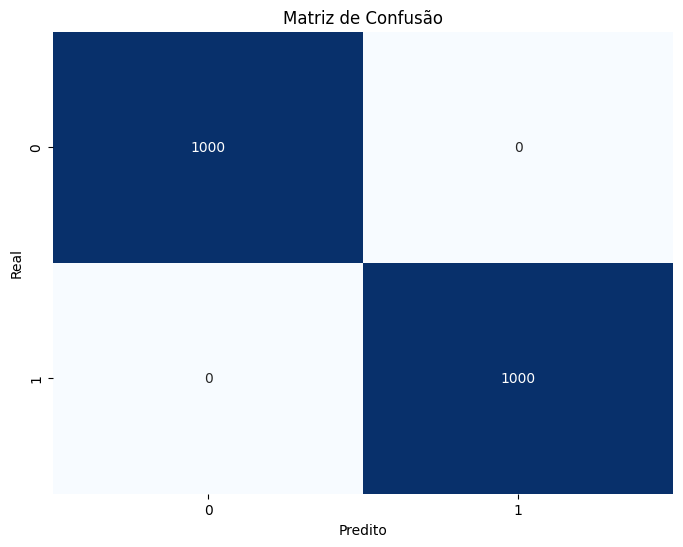

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Adição Dropout
Apesar de um bom resultado, os atuais valores estão variando muito. Por isso, aplicação de dropout com probabilidade de 0.5 será feita

In [ ]:
in_channels = 3
output_features = 2
learning_rate = 1e-2
weight_decay = 1e-4
dropout = 0.5

In [ ]:
model = torchvision.models.resnet50(num_classes=output_features)

In [ ]:
model.fc = torch.nn.Sequential(
  torch.nn.Dropout(dropout),
  torch.nn.Linear(model.fc.in_features, output_features)
)

In [ ]:
model = model.to("cuda")

In [ ]:
optimizer = torch.optim.Adamax(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08, weight_decay=weight_decay)

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 50)

Epoch 1/50 | Train Loss: 0.3164 | Val Loss: 0.7916 | Sem melhora: 0/50
Epoch 2/50 | Train Loss: 0.0586 | Val Loss: 0.1662 | Sem melhora: 0/50
Epoch 3/50 | Train Loss: 0.0429 | Val Loss: 0.8229 | Sem melhora: 1/50
Epoch 4/50 | Train Loss: 0.0366 | Val Loss: 5.3022 | Sem melhora: 2/50
Epoch 5/50 | Train Loss: 0.0524 | Val Loss: 0.0617 | Sem melhora: 0/50
Epoch 6/50 | Train Loss: 0.0511 | Val Loss: 1.9105 | Sem melhora: 1/50
Epoch 7/50 | Train Loss: 0.0200 | Val Loss: 2.0726 | Sem melhora: 2/50
Epoch 8/50 | Train Loss: 0.0176 | Val Loss: 0.2299 | Sem melhora: 3/50
Epoch 9/50 | Train Loss: 0.0139 | Val Loss: 0.3150 | Sem melhora: 4/50
Epoch 10/50 | Train Loss: 0.0103 | Val Loss: 0.0125 | Sem melhora: 0/50
Epoch 11/50 | Train Loss: 0.0233 | Val Loss: 0.1645 | Sem melhora: 1/50
Epoch 12/50 | Train Loss: 0.0055 | Val Loss: 0.1123 | Sem melhora: 2/50
Epoch 13/50 | Train Loss: 0.0134 | Val Loss: 0.9302 | Sem melhora: 3/50
Epoch 14/50 | Train Loss: 0.0190 | Val Loss: 0.0183 | Sem melhora: 4/50
E

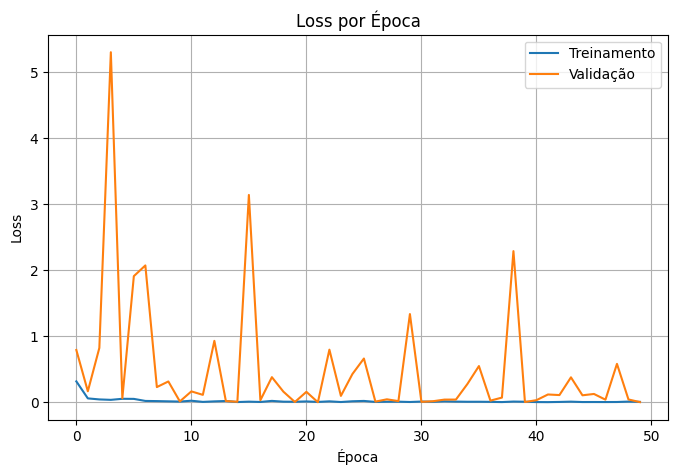

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 1.0000
Precisão (weighted): 1.0000
Recall (weighted): 1.0000
F1-score (weighted): 1.0000
Matriz de Confusão:
[[1000    0]
 [   0 1000]]


### Análise dos dados
O fato de não ter diminuido a variação da loss do validation, leva a crer uma possível problemática dos dados, no entanto os dados se mantém proporcionais, o que nos leva a crer que esse não é o problema.

In [ ]:
df_train['label'].value_counts()


,count
label,
1,3600
0,3600


In [ ]:
df_validation['label'].value_counts()


,count
label,
0,400
1,400


In [ ]:
df_test['label'].value_counts()


,count
label,
0,1000
1,1000
